In [1]:
#!pip list

## Step1 : importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
from sklearn import svm
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score, f1_score, classification_report

## Step 2: Data Imprting & Analysis

In [5]:
data_df = pd.read_csv("heart.csv")

In [6]:
data_df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [7]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


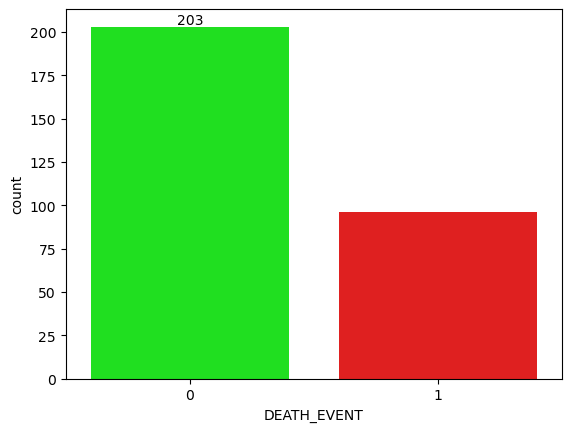

In [8]:
cols = ["#00FF00", "#FF0000"]
ax = sns.countplot(x=data_df["DEATH_EVENT"], hue=data_df["DEATH_EVENT"], palette=cols, legend=False)
ax.bar_label(ax.containers[0])
plt.show()

In [9]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


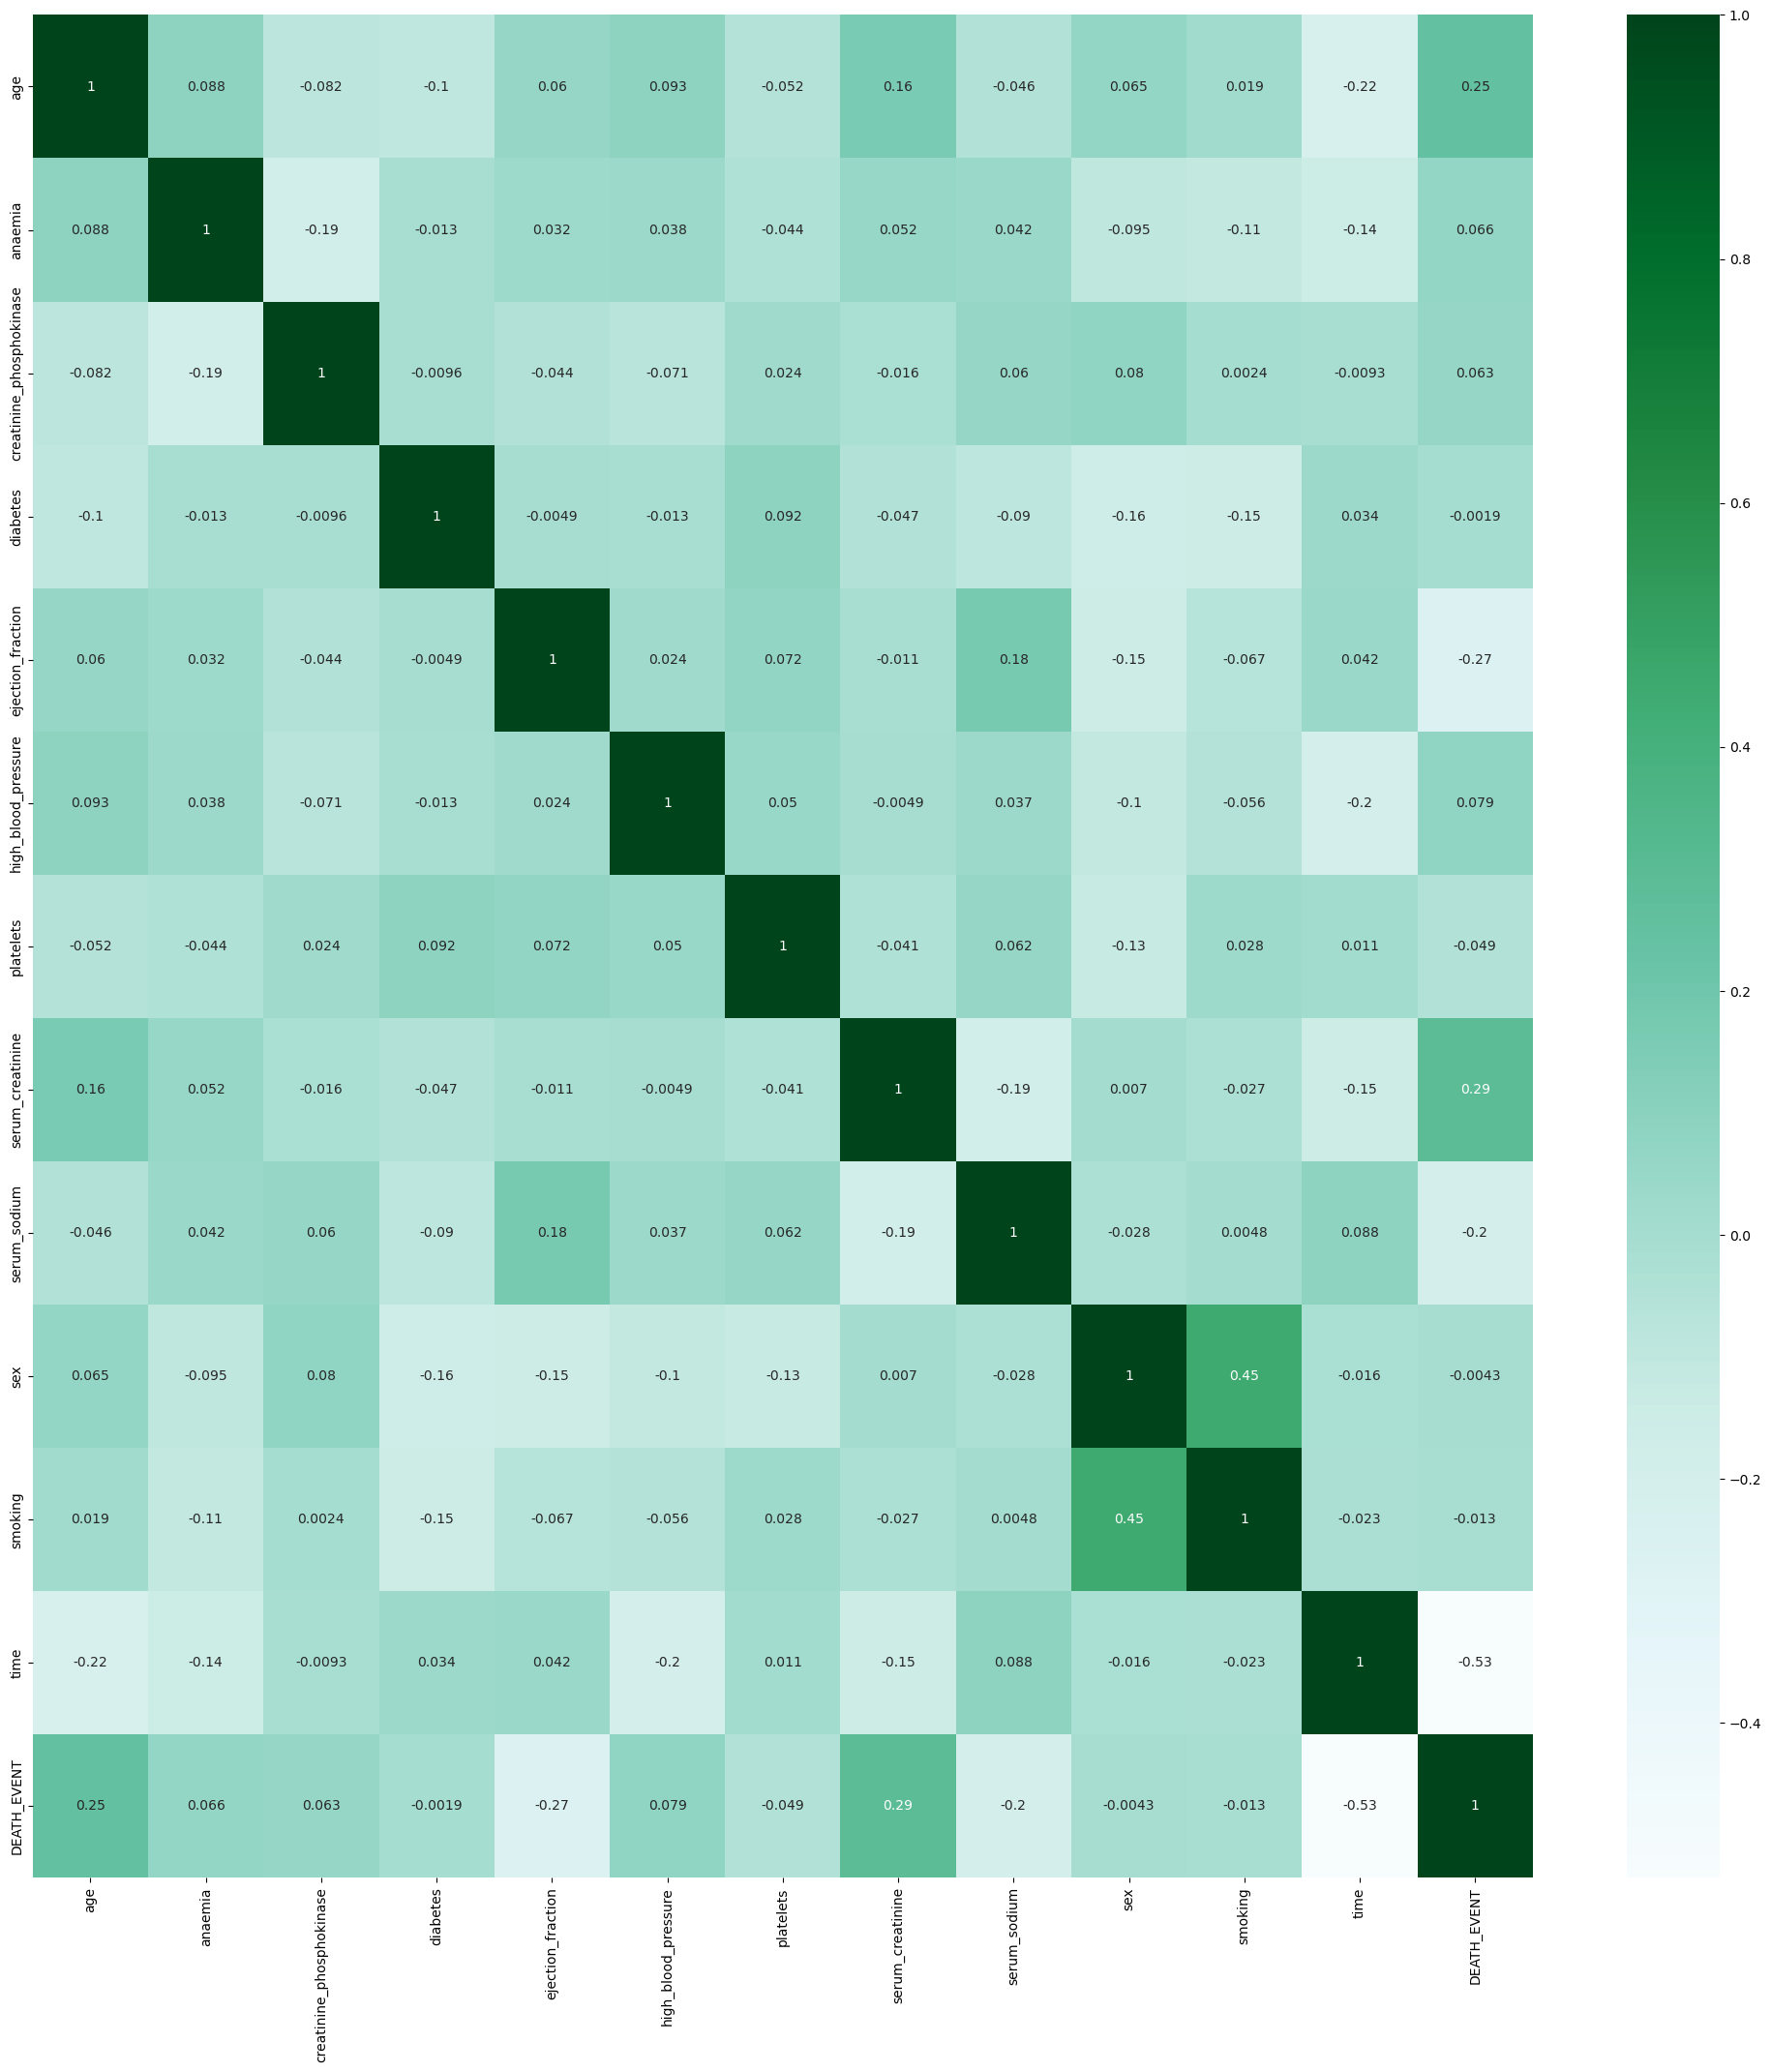

In [10]:
plt.subplots(figsize=(25,25))
sns.heatmap(data_df.corr(),cmap = "BuGn",annot=True)
plt.show()

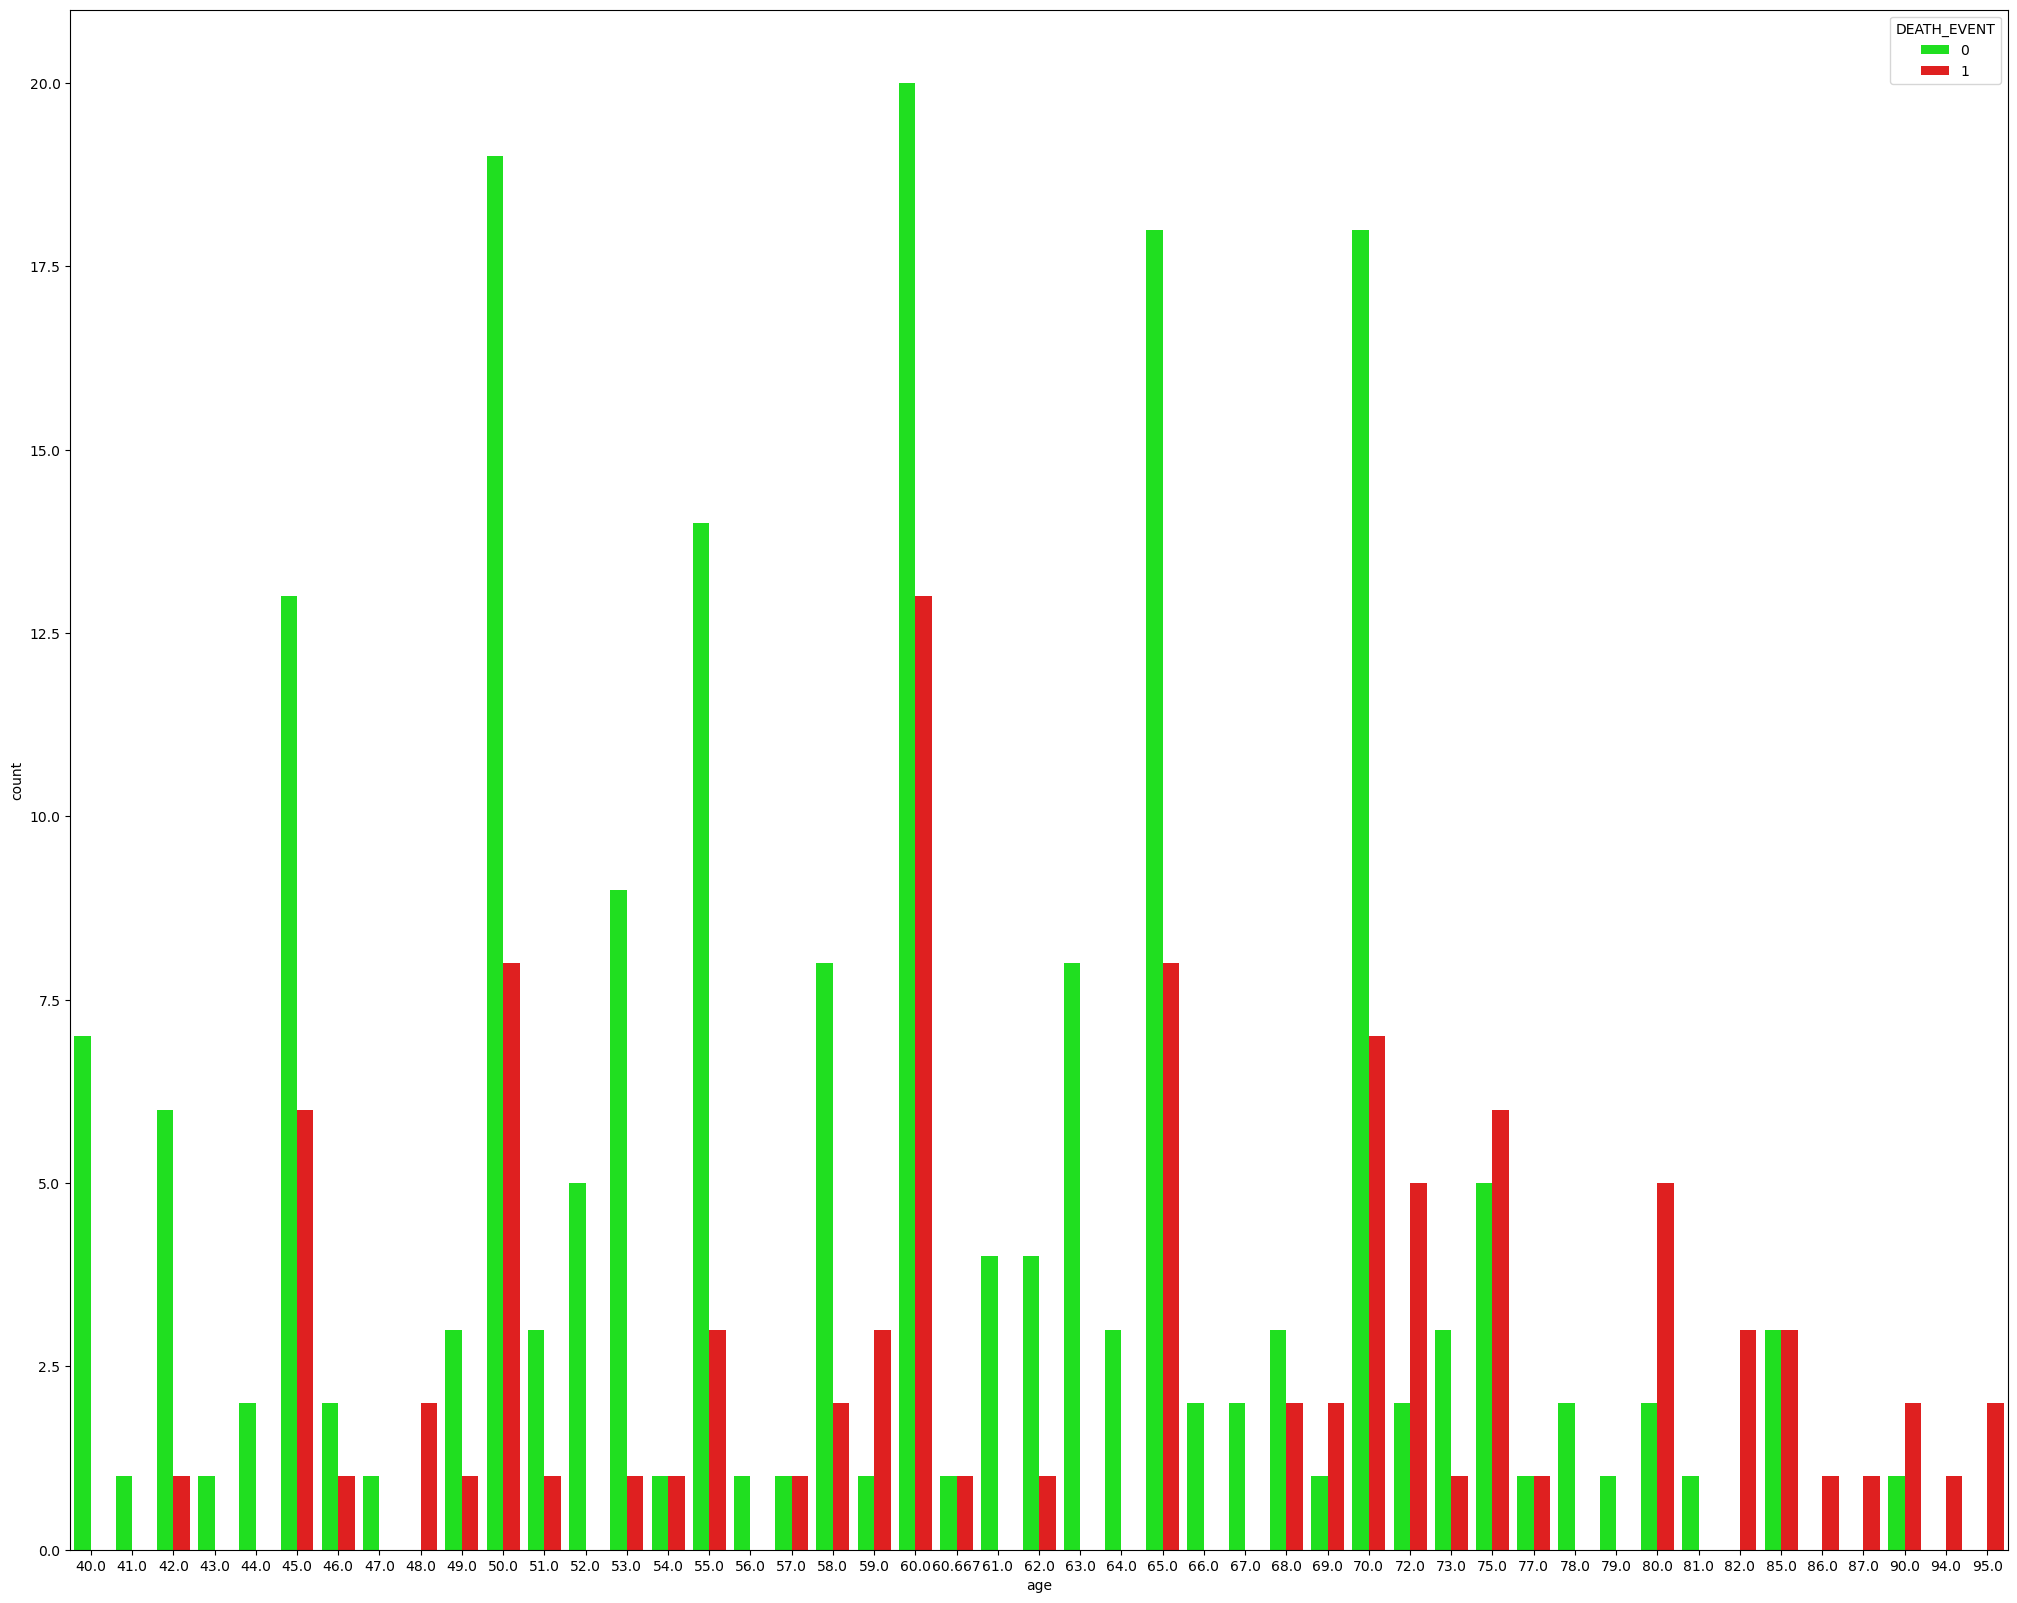

In [11]:
plt.figure(figsize=(25,20))
days_of_week = sns.countplot(x=data_df['age'],data=data_df,hue="DEATH_EVENT",palette=cols)

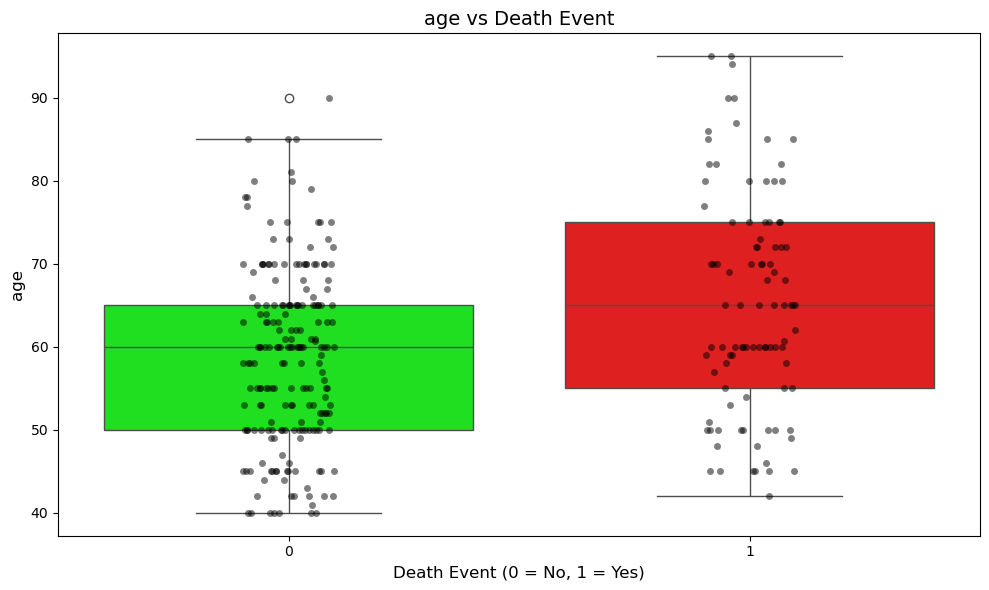

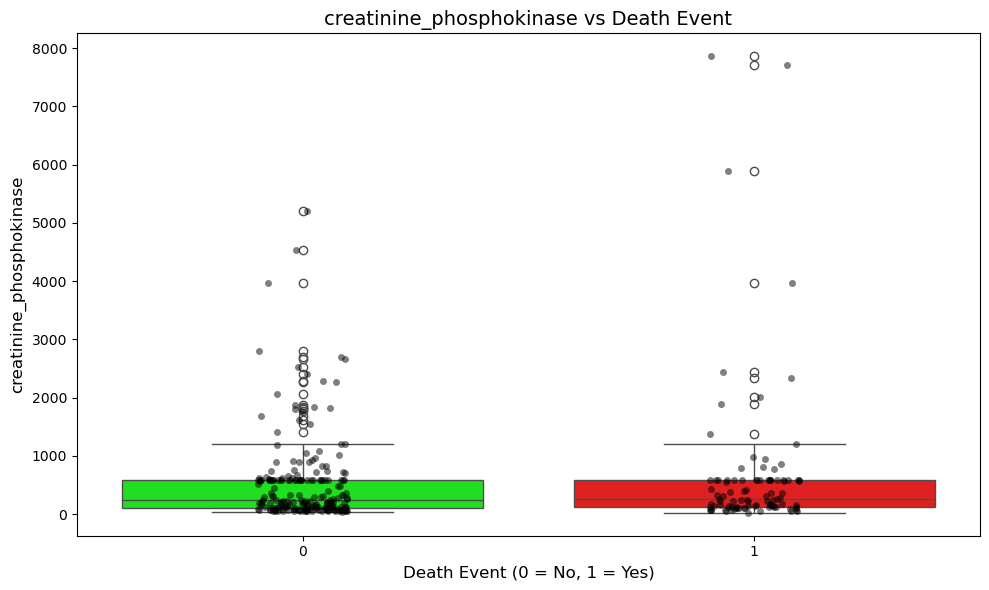

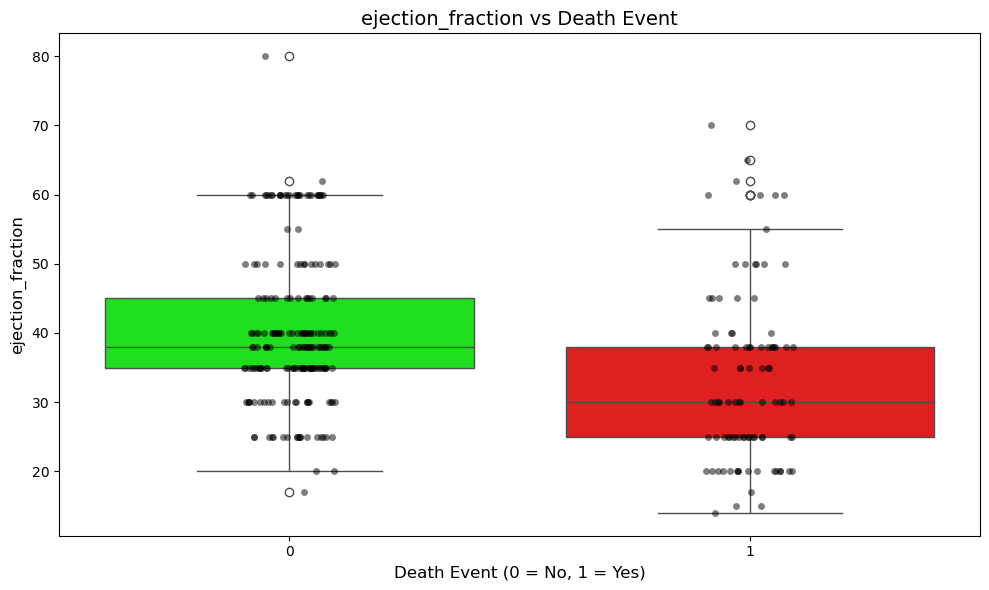

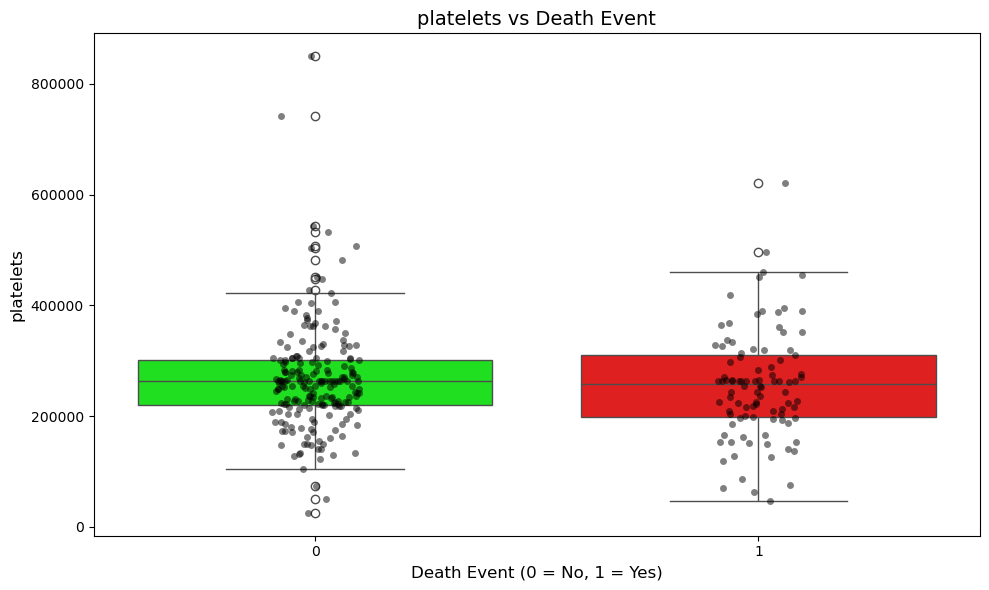

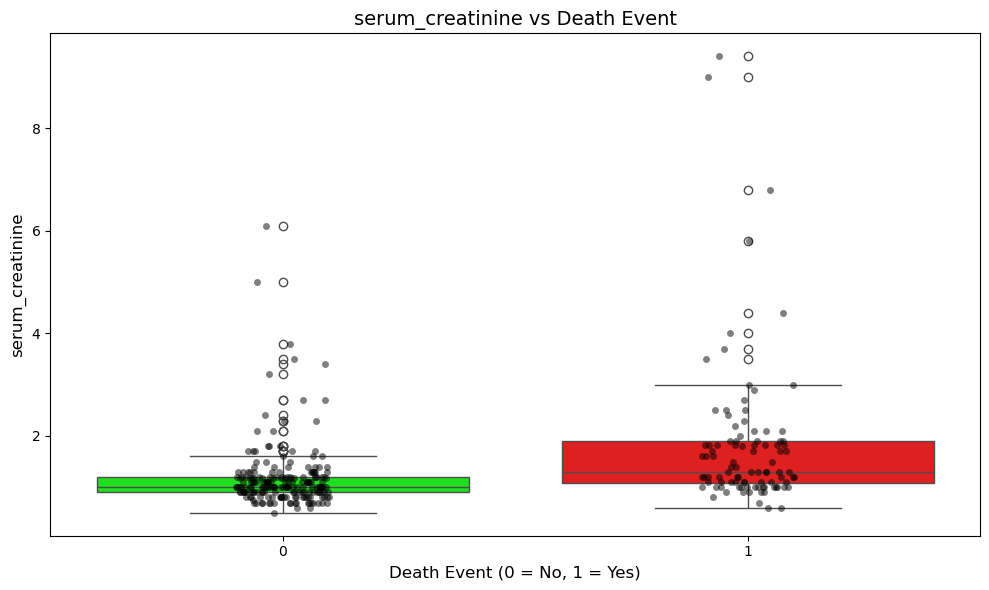

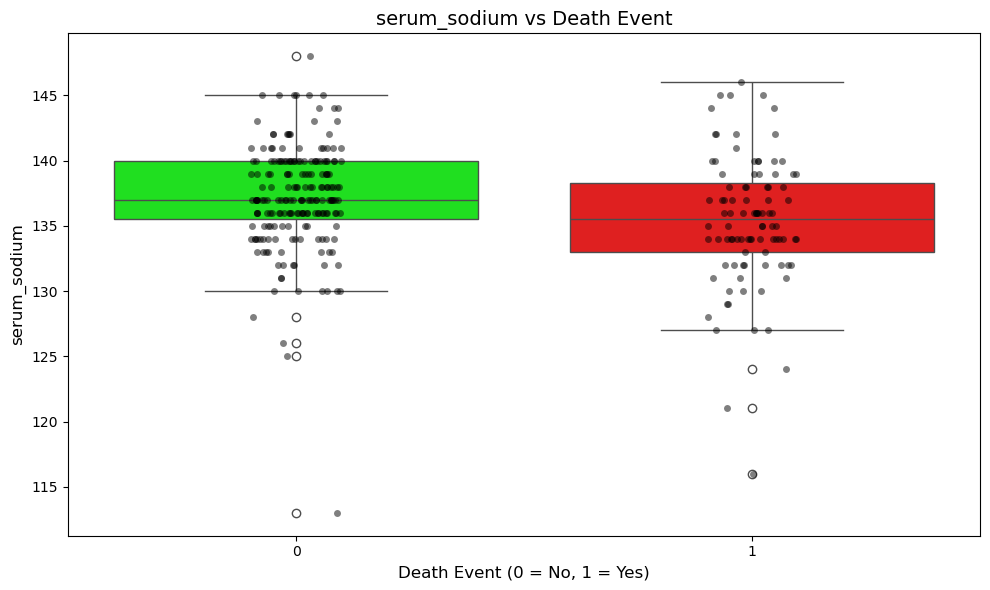

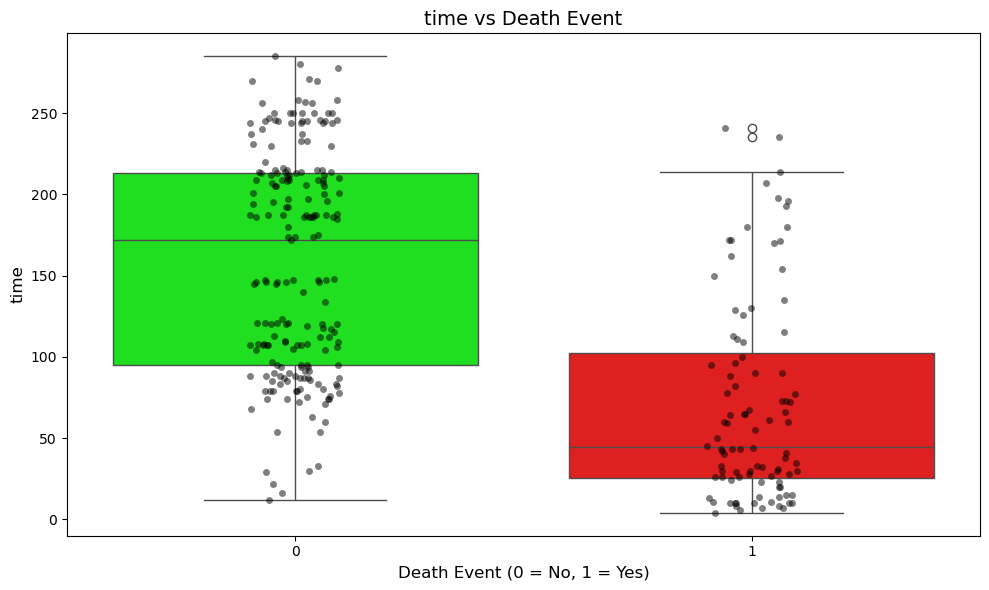

In [12]:
cols = ["#00FF00", "#FF0000"]

feature = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

for i in feature:
    plt.figure(figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(
        x=data_df["DEATH_EVENT"],
        y=data_df[i],
        hue=data_df["DEATH_EVENT"],
        palette=cols,
        legend=False
    )
    
    # Swarmplot
    sns.stripplot(
        x=data_df["DEATH_EVENT"],
        y=data_df[i],
        color="black",
        alpha=0.5
    )
    
    # Titles and labels
    plt.title(f"{i} vs Death Event", fontsize=14)
    plt.xlabel("Death Event (0 = No, 1 = Yes)", fontsize=12)
    plt.ylabel(i, fontsize=12)
    
    plt.tight_layout()
    plt.show()

## Step3 : Data Preprocessing

In [13]:
X=data_df.drop(["DEATH_EVENT"],axis=1)
y=data_df["DEATH_EVENT"]

In [14]:
col_name = list(X.columns)
s_scaler = preprocessing.StandardScaler()
X_scaled = s_scaler.fit_transform(X)
X_scaled= pd.DataFrame(X_scaled,columns=col_name)

In [15]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


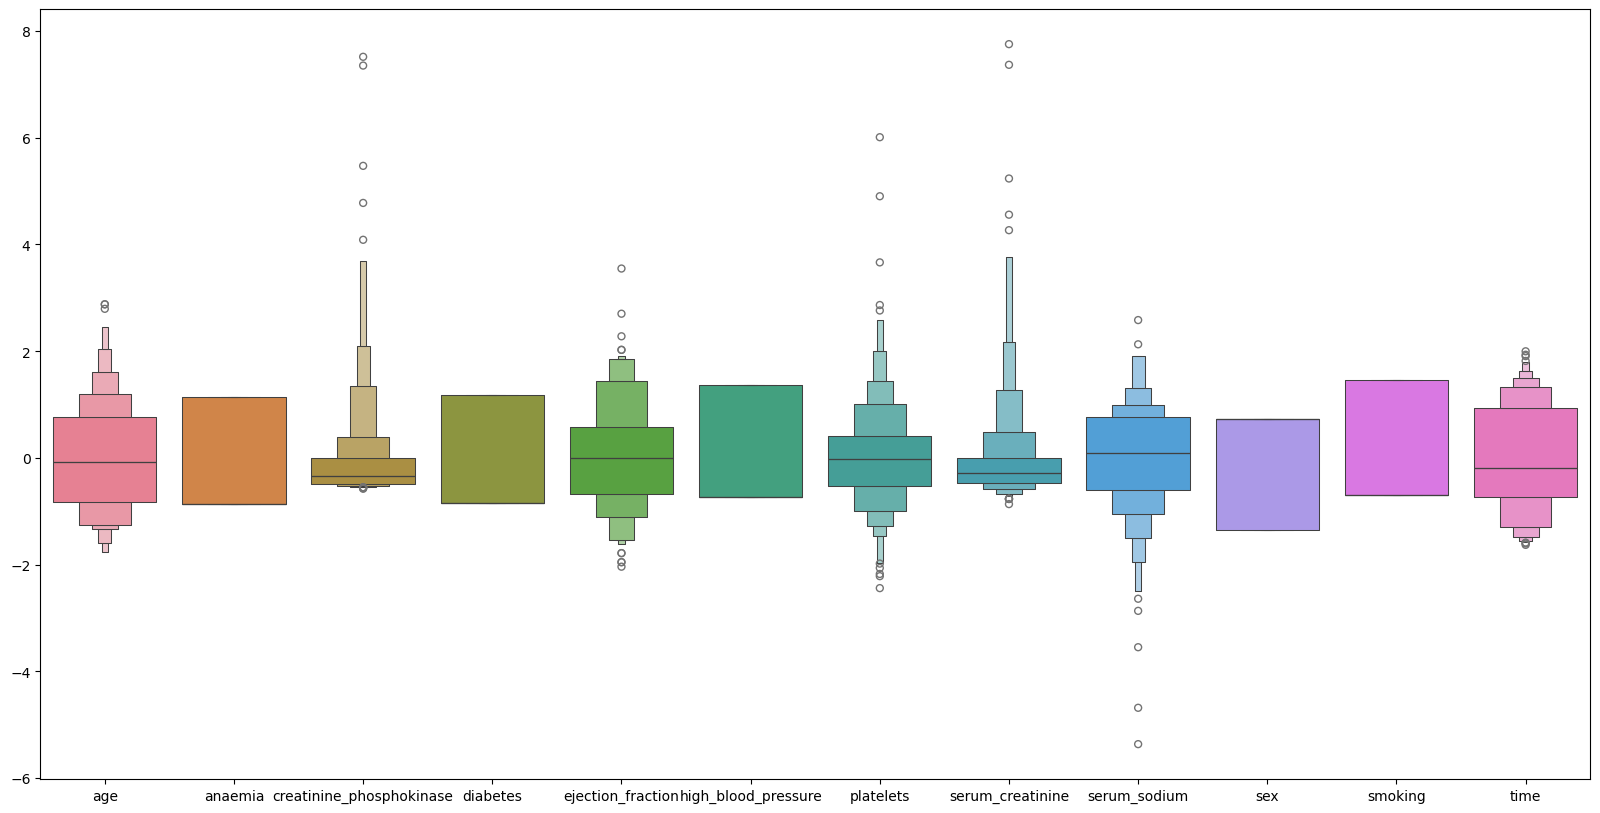

In [16]:
plt.figure(figsize=(20,10))
sns.boxenplot(data=X_scaled)
plt.show()

In [17]:
X_train,X_tests,y_train,y_test = train_test_split(X_scaled,y,test_size=0.3)

## Step4 : Model Building

## 1. SVM

In [18]:
model1 = svm.SVC()

In [19]:
model1.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
y_pred = model1.predict(X_tests)

In [21]:
y_pred

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0])

In [22]:
y_test

30     1
56     0
247    0
296    0
104    0
      ..
66     1
95     0
162    0
74     1
197    0
Name: DEATH_EVENT, Length: 90, dtype: int64

In [23]:
y_train

46     1
4      1
187    1
217    1
16     1
      ..
15     1
141    0
215    0
140    1
203    0
Name: DEATH_EVENT, Length: 209, dtype: int64

In [24]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85        58
           1       0.76      0.59      0.67        32

    accuracy                           0.79        90
   macro avg       0.78      0.75      0.76        90
weighted avg       0.79      0.79      0.78        90



## 2. ANN

In [25]:
# Early stopping
early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,
    patience=20,
    restore_best_weights=True
)
# Model
model = Sequential()
# Input layer + first hidden layer
model.add(Dense(units=16, kernel_initializer='uniform', activation='relu', input_dim=12))
# Second hidden layer
model.add(Dense(units=8, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.25))
# Third hidden layer
model.add(Dense(units=8, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.5))
# Output layer
model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

C:\AppData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 425 (1.66 KB)

 Trainable params: 425 (1.66 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history=model.fit(X_train,y_train,batch_size=25,epochs=100,callbacks=[early_stopping],validation_split=0.25)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6667 - loss: 0.6925 - val_accuracy: 0.6981 - val_loss: 0.6917
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6923 - loss: 0.6912 - val_accuracy: 0.6981 - val_loss: 0.6902
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6923 - loss: 0.6899 - val_accuracy: 0.6981 - val_loss: 0.6888
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6923 - loss: 0.6884 - val_accuracy: 0.6981 - val_loss: 0.6873
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6923 - loss: 0.6866 - val_accuracy: 0.6981 - val_loss: 0.6856
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6923 - loss: 0.6846 - val_accuracy: 0.6981 - val_loss: 0.6836
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6923 - loss: 0.6827 - val_accuracy: 0.6981 - val_loss: 0.6811
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6923 - loss: 0.6807 - val_accuracy: 0.6981 - val_loss:

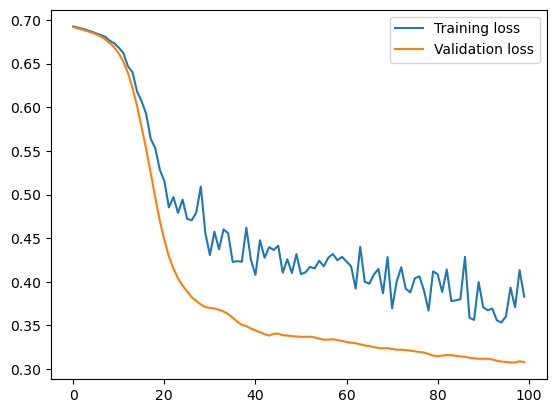

In [29]:
history_df = pd.DataFrame(history.history)
plt.plot(history_df.loc[:,['loss']],label="Training loss")
plt.plot(history_df.loc[:,['val_loss']],label="Validation loss")
plt.legend()
plt.show()

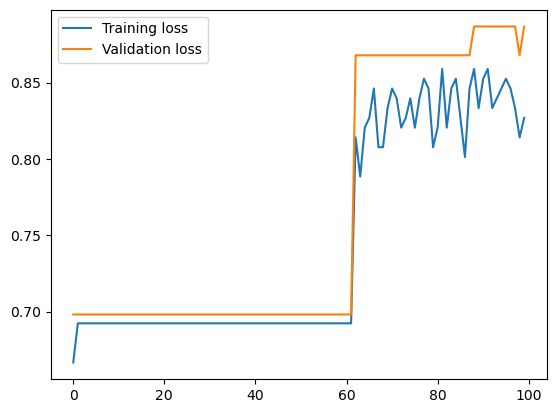

In [30]:
plt.plot(history_df.loc[:,['accuracy']],label="Training loss")
plt.plot(history_df.loc[:,['val_accuracy']],label="Validation loss")
plt.legend()
plt.show()

In [31]:
y_pred = model.predict(X_tests)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [32]:
y_pred = (y_pred>0.5)

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        58
           1       0.67      0.62      0.65        32

    accuracy                           0.76        90
   macro avg       0.73      0.73      0.73        90
weighted avg       0.75      0.76      0.75        90

